In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [2]:
countries = df['country']
df_clean = df.drop('country', axis=1)

df_clean.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df_clean.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [4]:
df_clean.isnull().sum()

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_df = scaler.fit_transform(df_clean)

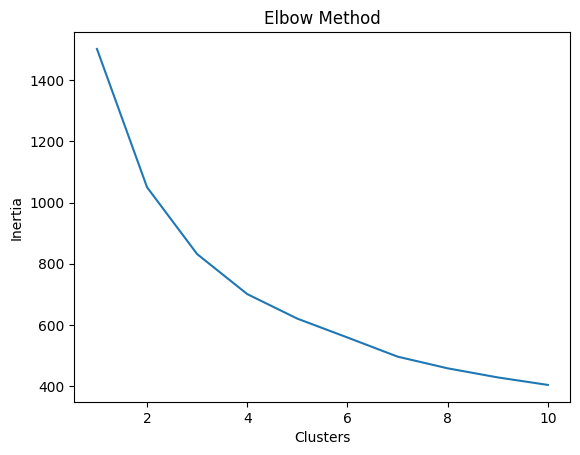

In [11]:
from sklearn.cluster import KMeans

inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_df)

df_clean['Cluster'] = clusters
df_clean['Country'] = countries

df_clean.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,Country
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,Afghanistan
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,Albania
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,Algeria
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,Angola
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,Antigua and Barbuda


In [13]:
df_clean.groupby('Cluster').mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


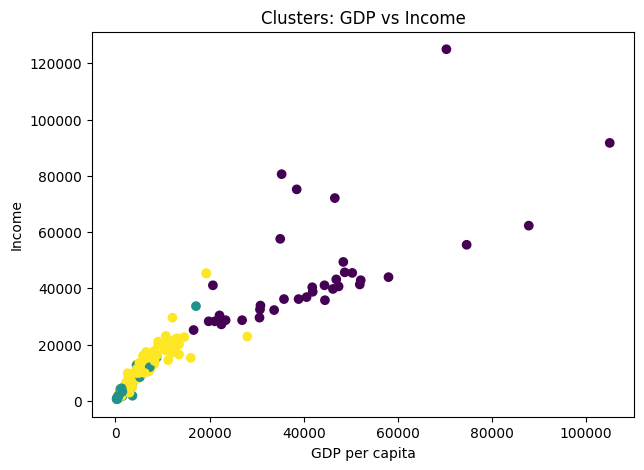

In [14]:
plt.figure(figsize=(7,5))
plt.scatter(df_clean['gdpp'], df_clean['income'], c=df_clean['Cluster'])
plt.xlabel("GDP per capita")
plt.ylabel("Income")
plt.title("Clusters: GDP vs Income")
plt.show()

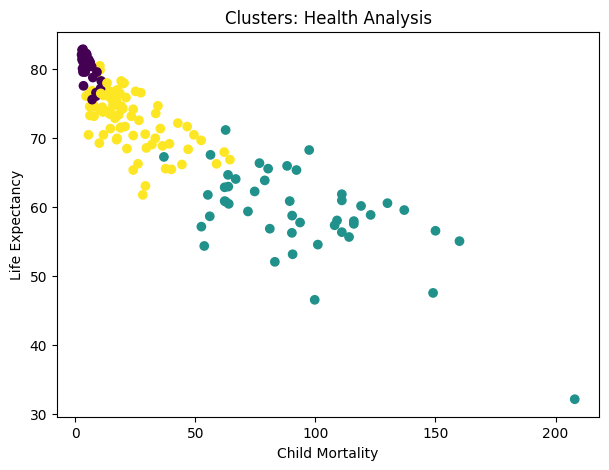

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(df_clean['child_mort'], df_clean['life_expec'], c=df_clean['Cluster'])
plt.xlabel("Child Mortality")
plt.ylabel("Life Expectancy")
plt.title("Clusters: Health Analysis")
plt.show()

KMeans clustering was applied on country socio-economic data after standardization.

Three clusters were identified:

Cluster 2: Underdeveloped countries with high child mortality and low income.
Cluster 0: Developing countries with moderate indicators.
Cluster 1: Developed countries with high income, GDP and life expectancy.

This analysis helps in identifying countries that need economic and healthcare support.